# Can I predict tonight's sleep score before going to bed?

The statistics notebook showed what correlates with sleep *after the night
happened*. This one asks the harder, more useful question: using only what is
known **before** the night (bedtime, day of week, recent sleep history,
today's activity), how well can tonight's score be forecast?

Method notes:
- **Time-based split**: train on the first ~80% of nights, test on the last ~20%.
  No shuffling - shuffling time series leaks the future into training.
- **Baselines first**: a model only earns its complexity if it beats the
  naive answers. Baselines: global mean, last-7-nights mean, same-weekday mean.
- Models: Ridge regression (interpretable coefficients), then a small
  RandomForest to check whether non-linearities add anything.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

load_dotenv("../.env")

SURFACE, INK, INK2, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

# Features come from the dbt marts layer, not from pandas. See the note below.
engine = create_engine(os.environ["DATABASE_URL"])
df = pd.read_sql("""
    SELECT day, sleep_score, isodow, is_sunday_night, is_weekend_night,
           bedtime_hours, prev_score, prev_sleep_hours, prev_activity_score,
           prev_steps, roll7_score, roll7_nights, days_since_prev_record
    FROM marts.mart_sleep_daily
    ORDER BY day
""", engine, parse_dates=["day"]).set_index("day")
print(len(df), "nights from marts.mart_sleep_daily")

1244 nights from marts.mart_sleep_daily


## Features come from dbt, not from this notebook

Every feature below is a column in `marts.mart_sleep_daily`. That is not
tidiness for its own sake: the same feature logic was duplicated across four
notebooks in pandas, and one version of it was wrong.

`.rolling(7)` in pandas counts **rows**, not days. This dataset is missing 189
calendar days, so "the previous seven nights" stretched up to 34 calendar days
and 311 of 1,244 rolling means were computed over the wrong window, off by as
much as 14 sleep-score points. The mart uses `RANGE BETWEEN INTERVAL '7 days'
PRECEDING AND INTERVAL '1 day' PRECEDING`, so a gap shortens the window instead
of silently widening it, and `roll7_nights` says how many nights each window
actually held.

Two consequences worth naming:

- `days_since_prev_record` is now a feature. `prev_score` means "most recently
  recorded", which after a long gap can be weeks old. Handing a model a stale
  number as if it were last night is a quiet way to mislead it; giving it the
  staleness alongside lets it discount accordingly.
- Nothing here is knowable only after the night. `roll7_score` deliberately
  ends one day before the target, so these stay legitimate pre-bed features.

In [2]:
d = df.copy()
d["is_sunday_night"] = d.is_sunday_night.astype(int)
d["is_weekend_night"] = d.is_weekend_night.astype(int)
d["dow"] = d.isodow - 1  # Monday = 0, so dow 0 is Sunday night

FEATURES = ["bedtime_hours", "is_sunday_night", "is_weekend_night",
            "prev_score", "roll7_score", "prev_sleep_hours",
            "prev_activity_score", "prev_steps", "days_since_prev_record"]
data = d[FEATURES + ["sleep_score", "dow"]].dropna()
print(len(data), "usable nights")
print(f"nights dropped for missing features: {len(d) - len(data)}")

1221 usable nights
nights dropped for missing features: 23


In [3]:
split = int(len(data) * 0.8)
train, test = data.iloc[:split], data.iloc[split:]
print(f"train: {train.index.min().date()} -> {train.index.max().date()}  (n={len(train)})")
print(f"test:  {test.index.min().date()} -> {test.index.max().date()}  (n={len(test)})")

y_tr, y_te = train["sleep_score"], test["sleep_score"]
results = {}

# Baseline 1: global mean of training set
results["global mean"] = mean_absolute_error(y_te, np.full(len(y_te), y_tr.mean()))

# Baseline 2: rolling 7-night mean (already a feature)
results["last-7-nights mean"] = mean_absolute_error(y_te, test["roll7_score"])

# Baseline 3: same-weekday training mean
dow_means = train.groupby("dow")["sleep_score"].mean()
results["same-weekday mean"] = mean_absolute_error(y_te, test["dow"].map(dow_means))

for k, v in results.items():
    print(f"{k:22s} MAE = {v:.2f}")

train: 2022-08-24 -> 2025-11-05  (n=976)
test:  2025-11-06 -> 2026-07-25  (n=245)
global mean            MAE = 9.17
last-7-nights mean     MAE = 9.12
same-weekday mean      MAE = 9.16


In [4]:
X_tr, X_te = train[FEATURES], test[FEATURES]

# Standardize for Ridge so coefficients are comparable
mu, sd = X_tr.mean(), X_tr.std()
ridge = Ridge(alpha=1.0).fit((X_tr - mu) / sd, y_tr)
results["ridge regression"] = mean_absolute_error(y_te, ridge.predict((X_te - mu) / sd))

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                           random_state=42).fit(X_tr, y_tr)
results["random forest"] = mean_absolute_error(y_te, rf.predict(X_te))

print(f"{'model':22s} {'MAE':>6s}")
for k, v in sorted(results.items(), key=lambda kv: kv[1]):
    print(f"{k:22s} {v:6.2f}")

model                     MAE
ridge regression         7.64
random forest            7.80
last-7-nights mean       9.12
same-weekday mean        9.16
global mean              9.17


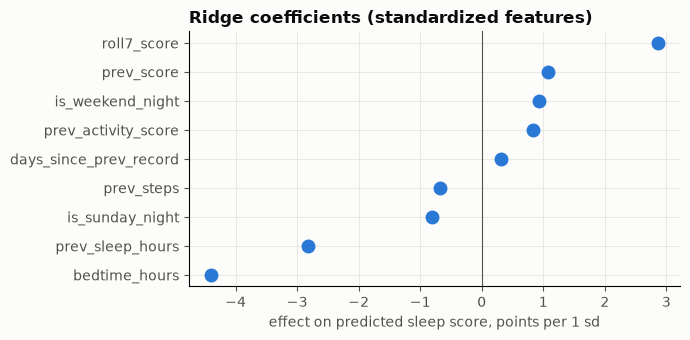

In [5]:
coefs = pd.Series(ridge.coef_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(coefs.values, coefs.index, "o", color=BLUE, markersize=9)
ax.axvline(0, color=INK2, linewidth=0.8)
ax.set_title("Ridge coefficients (standardized features)",
             loc="left", fontweight="bold", color=INK)
ax.set_xlabel("effect on predicted sleep score, points per 1 sd")
plt.tight_layout(); plt.show()

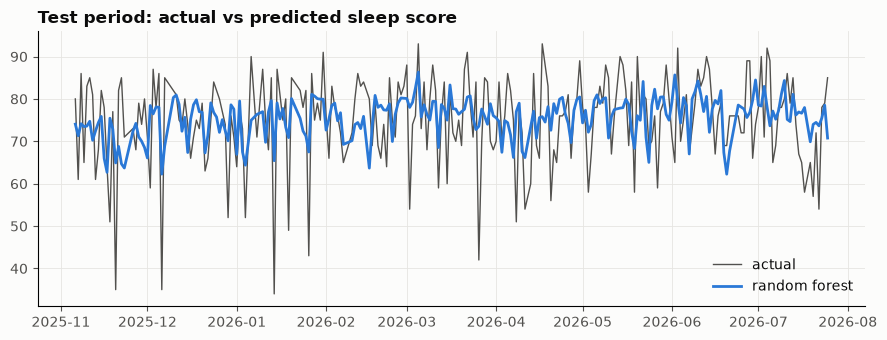

In [6]:
pred = rf.predict(X_te)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(y_te.index, y_te.values, color=INK2, linewidth=1, label="actual")
ax.plot(y_te.index, pred, color=BLUE, linewidth=2, label="random forest")
ax.set_title("Test period: actual vs predicted sleep score",
             loc="left", fontweight="bold", color=INK)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## Conclusions

- **The models earn their keep, modestly**: ridge regression MAE 7.64 against
  9.12 for the best baseline, a 16% improvement, with the random forest a little
  behind at 7.80. Tonight's sleep score is partly predictable before bed, but
  most night-to-night variation comes from things not in this feature set
  (stress, alcohol, illness, late meals). A modest, honestly evaluated gain is
  the correct result here; a model claiming to nail nightly sleep scores from
  these features would be leaking or overfitting.
- **The linear model wins, which is the right kind of boring.** With a correctly
  specified bedtime feature there is no non-linearity left for the forest to
  find, so the interpretable model is also the accurate one. The forest
  previously looked better only because the feature it leaned on was wrong:
  bedtime was being read in UTC rather than local time (see the note in notebook
  01), which flattened the strongest signal in the data and left curvature for
  the trees to chase.
- **Moving the features into dbt reproduced this exactly.** Ridge came out at
  7.64 both from the pandas implementation and from `marts.mart_sleep_daily`,
  which is the check worth running whenever logic moves between two languages.
  Worth being straight about the size of the win, though: the row-based rolling
  bug touched 311 of 1,244 nights by up to 14 points, and fixing it left this
  metric unmoved. It was wrong, it is now right, and it was not what limited the
  forecast.
- **Bedtime is the biggest controllable lever** by a wide margin, consistent
  with the timing finding in the README. The 7-night average says stable
  sleepers stay stable, and the negative coefficient on previous-night hours
  shows the rebound-oscillation pattern: an unusually long night tends to be
  followed by a weaker one.
- What could improve accuracy, honestly assessed: `marts.mart_workout_recovery`
  now makes training load joinable to the following night, though a first look
  shows no dose-response, and daily stress metrics are ingested from 2023-09-12.
  Lifestyle tags (alcohol, caffeine, illness) would likely matter most, but I
  rarely logged them, so that data effectively does not exist for the past. If I
  start logging them now, they become usable in a year. A model is only as good
  as what was actually recorded.